In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.integrate import quad
import math
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Fridge Details

In [3]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
# Assuming XLD1000sl
# We will use the operating temperatures and cable lengths corresponding to an XLD1000sl fridge
fridge = FRIDGE_LIBRARY["XLD1000SL"]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

# Thermal Conductivity

In [4]:
from library.cables import sc_085_nbti_conductivity

In [5]:
t_data = np.array([1, 1.5, 2, 3, 4, 5])
g_data = np.array([5.2E-7, 1E-6, 1.4E-6, 2.7E-6, 4.4E-6, 6.3E-6]) * 1E-2 # W.cm/Kelvin --> W.m/Kelvin

In [6]:
# Generate data points
x_vals = np.geomspace(10E-3, 5, num=100)
y_vals = sc_085_nbti_conductivity(x_vals) # W.cm/Kelvin 

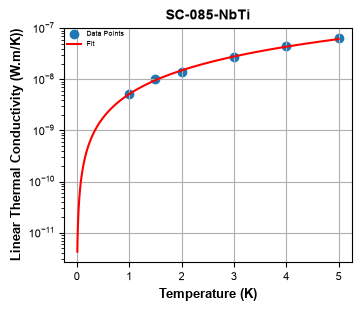

In [9]:
# Plot datapoints

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

ax.scatter(t_data, g_data, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_yscale('log')
# ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("SC-085-NbTi", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Linear Thermal Conductivity (W.m/K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./sc_086_nbti_thermal_conductivity.png",dpi=600)
plt.show()

In [8]:
# PHL for one SC-085-NbTi coax
def calc_PHL(cable_length_cm, T_lo, T_hi): # cable lengths in cm
    # Integrate cu_thermal_conductivity(T) from T_hi to T_lo
    result, error = quad(sc_085_nbti_conductivity, T_lo, T_hi)
    return result /(cable_length_cm)

print("PHL for SC-085-NbTi")
for temp_stage in TEMP_STAGES[3:]:
    # get cable length
    cable_length = flange_separation[temp_stage] # cm
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]
    
    PHL = calc_PHL(cable_length, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {PHL:.4e} W")

PHL for SC-085-NbTi
Still:	 1.5842e-09 W
CP:	 2.3992e-10 W
MXC:	 1.7168e-12 W
